In [1]:
# If needed, run this once:
# !pip install pandas numpy matplotlib scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [13]:
df = pd.read_csv("EarthSense_Transformer_Dataset_2001_rows_clean.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (2001, 8)


In [15]:
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset information:")
print(df.info())

             Timestamp Equipment_ID Earth_Pit_ID  Earth_Resistance_Ohm  \
0  2026-01-01 00:00:00        TR-01  TR-01-EP-01                 1.716   
1  2026-01-01 00:15:00        TR-01  TR-01-EP-02                 1.541   
2  2026-01-01 00:30:00        TR-01  TR-01-EP-03                 1.571   
3  2026-01-01 00:45:00        TR-01  TR-01-EP-04                 1.498   
4  2026-01-01 01:00:00        TR-01  TR-01-EP-01                 1.712   

   Soil_Moisture_Percent  Soil_Temperature_C  Soil_Resistivity_Ohm_m  \
0                  44.42               24.89                  103.55   
1                  50.02               25.61                   82.31   
2                  51.27               25.49                   91.92   
3                  50.86               26.93                   83.20   
4                  45.42               25.26                  102.96   

   Leakage_Current_mA  
0               19.00  
1               17.59  
2               20.87  
3               25.40  
4 

In [16]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Sort by Earth Pit and time
df = df.sort_values(
    ["Earth_Pit_ID", "Timestamp"]
).reset_index(drop=True)

# Calculate elapsed time in days for each Earth Pit
df["Days"] = (
    df.groupby("Earth_Pit_ID")["Timestamp"]
      .transform(
          lambda x: (x - x.min()).dt.total_seconds() / (24 * 60 * 60)
      )
)

print(df[["Timestamp", "Earth_Pit_ID", "Days"]].head(10))

            Timestamp Earth_Pit_ID      Days
0 2026-01-01 00:00:00  TR-01-EP-01  0.000000
1 2026-01-01 01:00:00  TR-01-EP-01  0.041667
2 2026-01-01 02:00:00  TR-01-EP-01  0.083333
3 2026-01-01 03:00:00  TR-01-EP-01  0.125000
4 2026-01-01 04:00:00  TR-01-EP-01  0.166667
5 2026-01-01 05:00:00  TR-01-EP-01  0.208333
6 2026-01-01 06:00:00  TR-01-EP-01  0.250000
7 2026-01-01 07:00:00  TR-01-EP-01  0.291667
8 2026-01-01 08:00:00  TR-01-EP-01  0.333333
9 2026-01-01 09:00:00  TR-01-EP-01  0.375000


In [17]:
parameters = [
    "Earth_Resistance_Ohm",
    "Leakage_Current_mA",
    "Soil_Moisture_Percent",
    "Soil_Temperature_C",
    "Soil_Resistivity_Ohm_m"
]

print("Parameters used for Linear Regression:")

for parameter in parameters:
    print("-", parameter)

Parameters used for Linear Regression:
- Earth_Resistance_Ohm
- Leakage_Current_mA
- Soil_Moisture_Percent
- Soil_Temperature_C
- Soil_Resistivity_Ohm_m


In [18]:
print("Missing values:")

print(df[parameters].isnull().sum())

Missing values:
Earth_Resistance_Ohm      0
Leakage_Current_mA        0
Soil_Moisture_Percent     0
Soil_Temperature_C        0
Soil_Resistivity_Ohm_m    0
dtype: int64


In [19]:
models = {}

for pit_id, pit_data in df.groupby("Earth_Pit_ID"):

    models[pit_id] = {}

    for parameter in parameters:

        # Select required data
        data = pit_data[["Days", parameter]].dropna()

        # Input = time
        X = data[["Days"]]

        # Output = sensor parameter
        y = data[parameter]

        # Create Linear Regression model
        model = LinearRegression()

        # Train model
        model.fit(X, y)

        # Store model
        models[pit_id][parameter] = model

print("All Linear Regression models trained successfully.")
print("Number of Earth Pits:", len(models))
print("Number of parameters per Earth Pit:", len(parameters))

All Linear Regression models trained successfully.
Number of Earth Pits: 40
Number of parameters per Earth Pit: 5


In [20]:
model_results = []

for pit_id in models:

    for parameter in parameters:

        model = models[pit_id][parameter]

        intercept = model.intercept_
        slope = model.coef_[0]

        model_results.append({
            "Earth_Pit_ID": pit_id,
            "Parameter": parameter,
            "Intercept_a": intercept,
            "Slope_b": slope
        })

model_results_df = pd.DataFrame(model_results)

model_results_df.head(20)

,Earth_Pit_ID,Parameter,Intercept_a,Slope_b
0,TR-01-EP-01,Earth_Resistance_Ohm,1.716490,0.077704
1,TR-01-EP-01,Leakage_Current_mA,18.599449,0.931352
2,TR-01-EP-01,Soil_Moisture_Percent,52.176425,-7.805321
3,TR-01-EP-01,Soil_Temperature_C,30.127790,-2.257455
4,TR-01-EP-01,Soil_Resistivity_Ohm_m,105.060008,8.229263
5,TR-01-EP-02,Earth_Resistance_Ohm,1.597452,0.049556
6,TR-01-EP-02,Leakage_Current_mA,17.638376,0.406554
7,TR-01-EP-02,Soil_Moisture_Percent,54.195482,-7.754138
8,TR-01-EP-02,Soil_Temperature_C,30.746094,-2.654590
9,TR-01-EP-02,Soil_Resistivity_Ohm_m,90.947835,4.625206


In [21]:
model_results_df["Trend"] = np.where(
    model_results_df["Slope_b"] > 0,
    "Increasing",
    np.where(
        model_results_df["Slope_b"] < 0,
        "Decreasing",
        "Stable"
    )
)

model_results_df.head(20)

,Earth_Pit_ID,Parameter,Intercept_a,Slope_b,Trend
0,TR-01-EP-01,Earth_Resistance_Ohm,1.716490,0.077704,Increasing
1,TR-01-EP-01,Leakage_Current_mA,18.599449,0.931352,Increasing
2,TR-01-EP-01,Soil_Moisture_Percent,52.176425,-7.805321,Decreasing
3,TR-01-EP-01,Soil_Temperature_C,30.127790,-2.257455,Decreasing
4,TR-01-EP-01,Soil_Resistivity_Ohm_m,105.060008,8.229263,Increasing
5,TR-01-EP-02,Earth_Resistance_Ohm,1.597452,0.049556,Increasing
6,TR-01-EP-02,Leakage_Current_mA,17.638376,0.406554,Increasing
7,TR-01-EP-02,Soil_Moisture_Percent,54.195482,-7.754138,Decreasing
8,TR-01-EP-02,Soil_Temperature_C,30.746094,-2.654590,Decreasing
9,TR-01-EP-02,Soil_Resistivity_Ohm_m,90.947835,4.625206,Increasing


In [22]:
metrics = []

for pit_id, pit_data in df.groupby("Earth_Pit_ID"):

    for parameter in parameters:

        data = pit_data[["Days", parameter]].dropna()

        X = data[["Days"]]
        y = data[parameter]

        model = models[pit_id][parameter]

        # Prediction
        y_pred = model.predict(X)

        # Metrics
        mae = mean_absolute_error(y, y_pred)

        rmse = np.sqrt(
            mean_squared_error(y, y_pred)
        )

        r2 = r2_score(y, y_pred)

        metrics.append({
            "Earth_Pit_ID": pit_id,
            "Parameter": parameter,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

metrics_df = pd.DataFrame(metrics)

metrics_df.head(20)

,Earth_Pit_ID,Parameter,MAE,RMSE,R2
0,TR-01-EP-01,Earth_Resistance_Ohm,0.053044,0.095083,0.200777
1,TR-01-EP-01,Leakage_Current_mA,0.730933,1.739446,0.097342
2,TR-01-EP-01,Soil_Moisture_Percent,3.387031,3.944293,0.595638
3,TR-01-EP-01,Soil_Temperature_C,2.052240,2.390723,0.251155
4,TR-01-EP-01,Soil_Resistivity_Ohm_m,6.332061,8.824142,0.246505
5,TR-01-EP-02,Earth_Resistance_Ohm,0.065157,0.080852,0.119580
6,TR-01-EP-02,Leakage_Current_mA,0.335420,0.745643,0.097051
7,TR-01-EP-02,Soil_Moisture_Percent,3.314360,4.072061,0.567286
8,TR-01-EP-02,Soil_Temperature_C,1.923959,2.244414,0.335887
9,TR-01-EP-02,Soil_Resistivity_Ohm_m,7.921525,8.964571,0.087793


In [23]:
print("Average Model Performance")

print(
    metrics_df[
        ["MAE", "RMSE", "R2"]
    ].mean()
)

Average Model Performance
MAE     3.577716
RMSE    4.469677
R2      0.214637
dtype: float64


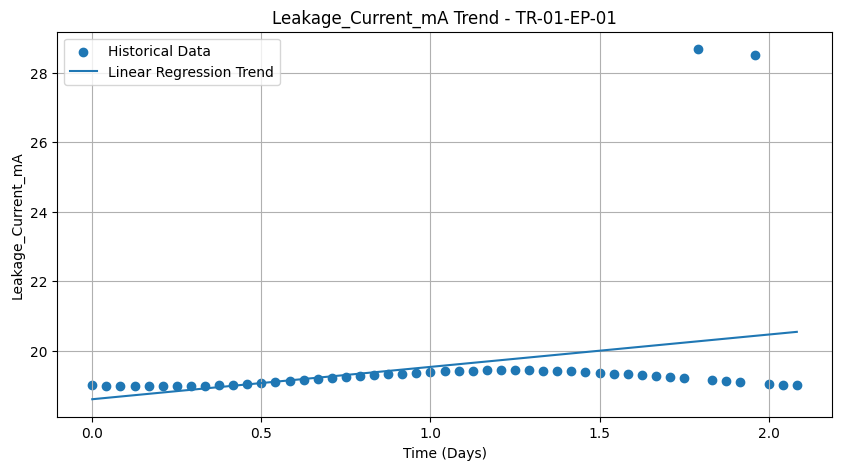

In [24]:
pit_id = "TR-01-EP-01"

parameter = "Leakage_Current_mA"

pit_data = df[
    df["Earth_Pit_ID"] == pit_id
].dropna(subset=["Days", parameter])

model = models[pit_id][parameter]

predicted = model.predict(
    pit_data[["Days"]]
)

plt.figure(figsize=(10, 5))

plt.scatter(
    pit_data["Days"],
    pit_data[parameter],
    label="Historical Data"
)

plt.plot(
    pit_data["Days"],
    predicted,
    label="Linear Regression Trend"
)

plt.xlabel("Time (Days)")
plt.ylabel(parameter)

plt.title(
    f"{parameter} Trend - {pit_id}"
)

plt.legend()
plt.grid(True)

plt.show()

In [25]:
pit_id = "TR-01-EP-01"

future_days = np.array([
    [10],
    [15],
    [20],
    [25],
    [30]
])

for parameter in parameters:

    model = models[pit_id][parameter]

    predictions = model.predict(future_days)

    print("\n", parameter)

    for day, prediction in zip(
        future_days.flatten(),
        predictions
    ):
        print(
            f"Day {day}: {prediction:.3f}"
        )


 Earth_Resistance_Ohm
Day 10: 2.494
Day 15: 2.882
Day 20: 3.271
Day 25: 3.659
Day 30: 4.048

 Leakage_Current_mA
Day 10: 27.913
Day 15: 32.570
Day 20: 37.226
Day 25: 41.883
Day 30: 46.540

 Soil_Moisture_Percent
Day 10: -25.877
Day 15: -64.903
Day 20: -103.930
Day 25: -142.957
Day 30: -181.983

 Soil_Temperature_C
Day 10: 7.553
Day 15: -3.734
Day 20: -15.021
Day 25: -26.309
Day 30: -37.596

 Soil_Resistivity_Ohm_m
Day 10: 187.353
Day 15: 228.499
Day 20: 269.645
Day 25: 310.792
Day 30: 351.938


In [26]:
thresholds = {
    "Earth_Resistance_Ohm": 2.0,
    "Leakage_Current_mA": 30.0,
    "Soil_Moisture_Percent": 30.0,
    "Soil_Temperature_C": 35.0,
    "Soil_Resistivity_Ohm_m": 120.0
}

print("Configured thresholds:")

for parameter, threshold in thresholds.items():
    print(parameter, "→", threshold)

Configured thresholds:
Earth_Resistance_Ohm → 2.0
Leakage_Current_mA → 30.0
Soil_Moisture_Percent → 30.0
Soil_Temperature_C → 35.0
Soil_Resistivity_Ohm_m → 120.0


In [27]:
def calculate_days_to_critical(
    current_value,
    threshold,
    slope
):

    # Parameter is increasing
    if slope > 0:

        # Threshold is in the future
        if threshold > current_value:
            days = (threshold - current_value) / slope
            return days

        # Threshold already crossed
        else:
            return -1

    # Parameter is decreasing
    elif slope < 0:

        # Threshold is in the future
        if threshold < current_value:
            days = (threshold - current_value) / slope
            return days

        # Threshold already crossed
        else:
            return -1

    # No degradation trend
    else:
        return np.inf

In [28]:
prediction_results = []

for pit_id, pit_data in df.groupby("Earth_Pit_ID"):

    # Latest reading for this Earth Pit
    latest_row = pit_data.sort_values(
        "Timestamp"
    ).iloc[-1]

    for parameter in parameters:

        model = models[pit_id][parameter]

        current_value = latest_row[parameter]

        threshold = thresholds[parameter]

        slope = model.coef_[0]

        days_to_critical = calculate_days_to_critical(
            current_value,
            threshold,
            slope
        )

        # Trend
        if slope > 0:
            trend = "Increasing"
        elif slope < 0:
            trend = "Decreasing"
        else:
            trend = "Stable"

        prediction_results.append({

            "Earth_Pit_ID": pit_id,

            "Parameter": parameter,

            "Current_Value": current_value,

            "Threshold": threshold,

            "Slope_per_Day": slope,

            "Trend": trend,

            "Estimated_Days_to_Critical":
                days_to_critical
        })

prediction_df = pd.DataFrame(
    prediction_results
)

prediction_df.head(20)

,Earth_Pit_ID,Parameter,Current_Value,Threshold,Slope_per_Day,Trend,Estimated_Days_to_Critical
0,TR-01-EP-01,Earth_Resistance_Ohm,1.718,2.0,0.077704,Increasing,3.629179
1,TR-01-EP-01,Leakage_Current_mA,19.010,30.0,0.931352,Increasing,11.800049
2,TR-01-EP-01,Soil_Moisture_Percent,44.170,30.0,-7.805321,Decreasing,1.815428
3,TR-01-EP-01,Soil_Temperature_C,24.800,35.0,-2.257455,Decreasing,-1.000000
4,TR-01-EP-01,Soil_Resistivity_Ohm_m,103.710,120.0,8.229263,Increasing,1.979521
5,TR-01-EP-02,Earth_Resistance_Ohm,1.545,2.0,0.049556,Increasing,9.181565
6,TR-01-EP-02,Leakage_Current_mA,17.600,30.0,0.406554,Increasing,30.500279
7,TR-01-EP-02,Soil_Moisture_Percent,48.850,30.0,-7.754138,Decreasing,2.430960
8,TR-01-EP-02,Soil_Temperature_C,25.130,35.0,-2.654590,Decreasing,-1.000000
9,TR-01-EP-02,Soil_Resistivity_Ohm_m,82.870,120.0,4.625206,Increasing,8.027750


In [29]:
overall_results = []

for pit_id in prediction_df["Earth_Pit_ID"].unique():

    pit_predictions = prediction_df[
        prediction_df["Earth_Pit_ID"] == pit_id
    ]

    valid_days = pit_predictions[
        pit_predictions[
            "Estimated_Days_to_Critical"
        ] >= 0
    ]["Estimated_Days_to_Critical"]

    if len(valid_days) > 0:

        d_min = valid_days.min()

    else:

        d_min = np.inf

    # Risk status
    if d_min < 0:
        risk = "Critical"

    elif d_min <= 7:
        risk = "High"

    elif d_min <= 30:
        risk = "Medium"

    else:
        risk = "Low"

    overall_results.append({

        "Earth_Pit_ID": pit_id,

        "Estimated_Days_to_Critical":
            d_min,

        "Risk_Status": risk
    })

overall_df = pd.DataFrame(
    overall_results
)

overall_df

,Earth_Pit_ID,Estimated_Days_to_Critical,Risk_Status
0,TR-01-EP-01,1.815428,High
1,TR-01-EP-02,2.430960,High
2,TR-01-EP-03,3.320377,High
3,TR-01-EP-04,3.868517,High
4,TR-02-EP-01,11.493037,Medium
5,TR-02-EP-02,27.212068,Medium
6,TR-02-EP-03,26.107897,Medium
7,TR-02-EP-04,inf,Low
8,TR-03-EP-01,inf,Low
9,TR-03-EP-02,inf,Low


In [30]:
final_output = prediction_df.merge(
    overall_df,
    on="Earth_Pit_ID",
    suffixes=("", "_Overall")
)

final_output.head(20)

,Earth_Pit_ID,Parameter,Current_Value,Threshold,Slope_per_Day,Trend,Estimated_Days_to_Critical,Estimated_Days_to_Critical_Overall,Risk_Status
0,TR-01-EP-01,Earth_Resistance_Ohm,1.718,2.0,0.077704,Increasing,3.629179,1.815428,High
1,TR-01-EP-01,Leakage_Current_mA,19.010,30.0,0.931352,Increasing,11.800049,1.815428,High
2,TR-01-EP-01,Soil_Moisture_Percent,44.170,30.0,-7.805321,Decreasing,1.815428,1.815428,High
3,TR-01-EP-01,Soil_Temperature_C,24.800,35.0,-2.257455,Decreasing,-1.000000,1.815428,High
4,TR-01-EP-01,Soil_Resistivity_Ohm_m,103.710,120.0,8.229263,Increasing,1.979521,1.815428,High
5,TR-01-EP-02,Earth_Resistance_Ohm,1.545,2.0,0.049556,Increasing,9.181565,2.430960,High
6,TR-01-EP-02,Leakage_Current_mA,17.600,30.0,0.406554,Increasing,30.500279,2.430960,High
7,TR-01-EP-02,Soil_Moisture_Percent,48.850,30.0,-7.754138,Decreasing,2.430960,2.430960,High
8,TR-01-EP-02,Soil_Temperature_C,25.130,35.0,-2.654590,Decreasing,-1.000000,2.430960,High
9,TR-01-EP-02,Soil_Resistivity_Ohm_m,82.870,120.0,4.625206,Increasing,8.027750,2.430960,High


In [31]:
final_output.to_csv(
    "EarthSense_Prediction_Output.csv",
    index=False
)

metrics_df.to_csv(
    "EarthSense_Model_Metrics.csv",
    index=False
)

model_results_df.to_csv(
    "EarthSense_Linear_Regression_Parameters.csv",
    index=False
)

print("Prediction output saved.")
print("Model metrics saved.")
print("Model parameters saved.")

Prediction output saved.
Model metrics saved.
Model parameters saved.


In [32]:
joblib.dump(
    models,
    "EarthSense_Linear_Regression_Models.joblib"
)

print("Trained models saved successfully.")

Trained models saved successfully.
